In [1]:
##PCA STEP BY STEP
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)
     

df.head()
     

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [4]:
# %pip install plotly
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color=df['target'].astype(str)
)

fig.update_traces(marker=dict(size=6))

fig.show()

In [3]:
scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])
df.head()

,feature1,feature2,feature3,target
2,-0.700809,-1.525586,-1.749156,1
34,-0.224481,-1.010757,0.491251,0
14,-0.011456,-0.046935,-0.649616,1
11,1.342296,-0.962723,-1.184163,1
12,-2.571350,-0.299561,-0.054040,1


In [5]:
covariance_matrix = np.cov(
    df.iloc[:, 0:3],
    rowvar=False
)

print("Covariance Matrix:\n")
print(covariance_matrix)

Covariance Matrix:

[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [6]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("Eigenvalues:")
print(eigen_values)

print("\nEigenvectors:")
print(eigen_vectors)

Eigenvalues:
[1.3536065  0.94557084 0.77774573]

Eigenvectors:
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


In [7]:
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

print("Sorted Eigenvalues:")
print(eigen_values)

print("\nSorted Eigenvectors:")
print(eigen_vectors)

Sorted Eigenvalues:
[1.3536065  0.94557084 0.77774573]

Sorted Eigenvectors:
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


In [8]:
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("Explained Variance Ratio:")
print(explained_variance_ratio)

print("\nPercentage:")
print(explained_variance_ratio * 100)

Explained Variance Ratio:
[0.43992211 0.30731052 0.25276736]

Percentage:
[43.99221135 30.73105232 25.27673634]


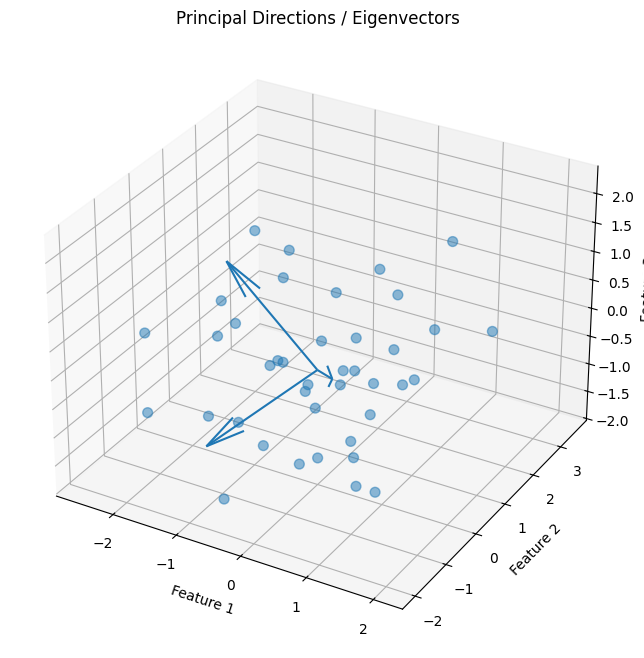

In [9]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=50,
    alpha=0.5
)

mean = df.iloc[:, 0:3].mean().values

for i in range(3):

    v = eigen_vectors[:, i]

    ax.quiver(
        mean[0], mean[1], mean[2],
        v[0], v[1], v[2],
        length=2,
        normalize=True
    )

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.title('Principal Directions / Eigenvectors')

plt.show()

In [10]:
pc = eigen_vectors[:, 0:2]

print("Selected Principal Components:")
print(pc)

Selected Principal Components:
[[-0.53875915 -0.69363291]
 [-0.65608325 -0.01057596]
 [-0.52848211  0.72025103]]


In [11]:
X = df.iloc[:, 0:3].values

transformed_df = np.dot(X, pc)

print(transformed_df.shape)

(40, 2)


In [12]:
new_df = pd.DataFrame(
    transformed_df,
    columns=['PC1', 'PC2']
)

new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,2.302877,-0.757593,1
1,0.524464,0.520221,0
2,0.380275,-0.459443,1
3,0.534262,-1.773773,1
4,1.610434,1.747819,1


In [13]:
new_df['target'] = new_df['target'].astype(str)

fig = px.scatter(
    new_df,
    x='PC1',
    y='PC2',
    color='target'
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2)
    )
)

fig.show()